Панова Светлана 09.07.14п2



Задание 1
Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загружаем датасет

In [2]:
df=pd.read_csv('/content/train.csv')

Задание 2
Определяем кол-во строк и столбцов

In [3]:
df.shape

(891, 12)

Названия всех столбцов

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Типы данных для всех столбцов

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Задание 3
Определяем кол-во пассажиров в каждом классе

In [6]:
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


Определяем кол-во мужчин и женщин

In [7]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


Разделение пассажиров на возрастные группы

In [26]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Дети (0-12)', 'Подростки (13-18)', 'Молодые (19-35)', 'Взрослые (36-60)', 'Пожилые (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df['AgeGroup'].value_counts().sort_index()

,count
AgeGroup,
Дети (0-12),69
Подростки (13-18),70
Молодые (19-35),358
Взрослые (36-60),195
Пожилые (60+),22


Определяем средний возраст

In [10]:
df['Age'].mean()

np.float64(29.69911764705882)

Определяем медианный возраст

In [11]:
df['Age'].median()

28.0

Определяем среднюю стоимость билета

In [12]:
df['Fare'].mean()

np.float64(32.204207968574636)

Задание 4

Средняя стоимость билета для каждого класса

In [14]:
df.groupby('Pclass')['Fare'].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


Средний возраст пассажиров в каждом классе

In [15]:
df.groupby('Pclass')['Age'].mean()

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


Определяем в каком классе больше всего пассажиров

In [16]:
df['Pclass'].value_counts().idxmax()

np.int64(3)

Билеты в 1 класс дороже чем во 2 и 3, примерно в 4 раза. В 1 классе возраст больше на 10 лет чем во 2 и 3. Меньше всего мужчин и женщин во 2 классе, а больше всего в 3.

Находим самый дорогой билет и все данные о билете

In [18]:
max_fare = df.loc[df['Fare'].idxmax()]

In [19]:
max_fare[['Pclass', 'Age', 'Sex', 'Survived', 'Fare']]

,258
Pclass,1
Age,35.0
Sex,female
Survived,1
Fare,512.3292


Задание 5
Определяем общее кол-во выживших и погибших

In [22]:
df['Survived'].value_counts().rename({0: 'Погибшие', 1: 'Выжившие'})

,count
Survived,
Погибшие,549
Выжившие,342


Сравниваем выживаемость мужчин и женщин

In [24]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


Сравниваем выживаемость мужчин и женщин для каждого класса

In [28]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

Определяем какая группа пассажиров имела наибольшую долю выживших

In [32]:
best = df.groupby(['Pclass', 'Sex'])['Survived'].mean().idxmax()
print(f"Наибольшая доля выживших: класс {best[0]}, пол {best[1]}")

Наибольшая доля выживших: класс 1, пол female


Задание 6
Строим график кол-ва пассажиров по классам

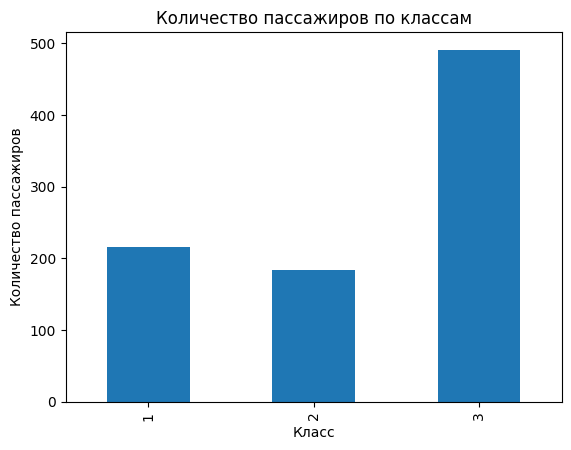

In [40]:
df['Pclass'].value_counts().sort_index().plot(kind='bar')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.show()

Строим график выживаемости по полу

(0.0, 1.0)

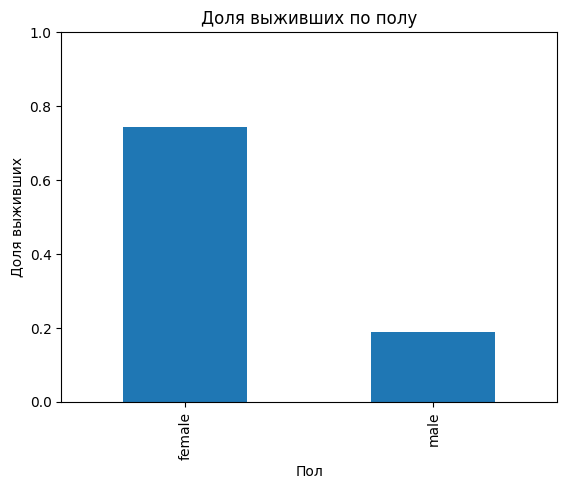

In [42]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)

У кого выживаемость выше — у детей или у взрослых?

In [47]:
df['IsChild'] = df['Age'] < 18
df.groupby('IsChild')['Survived'].agg(['mean', 'count']).round(3)

,mean,count
IsChild,,
False,0.361,778
True,0.540,113


In [ ]:
Дети (до 18 лет) выживали в 54% случаев.
Взрослые — только в 36%.